In [52]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from pathlib import Path
from scipy.interpolate import interp1d

In [53]:
# Constants
exp_data = """1.99	0.2570
3.99	0.2631
5.99	0.2681
7.99	0.2737
9.99	0.2809
11.99	0.2895
13.99	0.2990
15.99	0.3121
17.99	0.3273
19.99	0.3464
21.99	0.3726
23.99	0.4080
24.99	0.4320
25.89	0.4593
26.29	0.4722
26.69	0.4882
27.09	0.5057
27.49	0.5285
27.89	0.5488
28.34	0.5786
28.79	0.6183
29.04	0.6440
29.29	0.6732
29.54	0.7147
29.79	0.7527
30.04	0.8060
30.29	0.8609
30.39	0.8867
30.49	0.9170
30.59	0.9394
30.69	0.9611
30.79	0.9775
30.89	0.9907
30.99	1.0000
31.09	0.9969
31.19	0.9918
31.29	0.9767
31.39	0.9506
31.49	0.9161
31.59	0.8811
31.69	0.8314
31.89	0.7251
32.09	0.6001
32.29	0.4737
32.49	0.3549
32.69	0.2512
32.89	0.1638
33.09	0.0979
33.29	0.0540
33.49	0.0274
33.69	0.0133
33.89	0.0046
34.09	0.0016
34.29	0.0006
34.69	0.0000
35.09	0.0000
35.49	0.0000
"""


In [54]:
# Threshold for ratio calculation
THRESHOLD = 0.1

In [55]:
csv_file = Path('graph_z_profile_DOSE.csv')

In [56]:
def calculate_dose_metrics(df_data, data_name="Data", ref_x_coord=None, interp_func=None):
    """
    Calculate dose metrics for a dataset.
    
    Parameters:
    - df_data: DataFrame with 'depth' (in mm) and 'dose' (normalized) columns, or 'x' and 'y'
    - data_name: Name of the dataset for display
    - ref_x_coord: Reference x-coordinate for interpolating the first point (used for MC data)
    - interp_func: Interpolation function to use for first point value (used for MC data)
    
    Returns:
    - Dictionary with calculated metrics
    """
    if df_data is None or df_data.empty:
        print(f"{data_name} not loaded")
        return None
    
    # Determine column names
    x_col = 'x' if 'x' in df_data.columns else 'depth'
    y_col = 'y' if 'y' in df_data.columns else 'dose'
    
    metrics = {}
    
    # 1. Find distance where dose is 0.9 (scanning right to left) - called "Range"
    dose_09 = None
    for i in range(len(df_data) - 1, 0, -1):
        y_curr = df_data[y_col].iloc[i]
        y_prev = df_data[y_col].iloc[i-1]
        # Check for transition where we cross 0.9
        if y_curr <= 0.9 and y_prev > 0.9:
            x_curr, x_prev = df_data[x_col].iloc[i], df_data[x_col].iloc[i-1]
            # Linear interpolation to find x where y = 0.9
            dose_09 = x_prev + (0.9 - y_prev) * (x_curr - x_prev) / (y_curr - y_prev)
            break
    
    # 1b. Find distance where dose drops to 0.1 (scanning right to left)
    dose_01 = None
    for i in range(len(df_data) - 1, 0, -1):
        y_curr = df_data[y_col].iloc[i]
        y_prev = df_data[y_col].iloc[i-1]
        # Check for transition where we cross 0.1
        if y_curr <= 0.1 and y_prev > 0.1:
            x_curr, x_prev = df_data[x_col].iloc[i], df_data[x_col].iloc[i-1]
            # Linear interpolation to find x where y = 0.1
            dose_01 = x_prev + (0.1 - y_prev) * (x_curr - x_prev) / (y_curr - y_prev)
            break
    
    # Calculate drop distance from 0.9 to 0.1
    dose_drop_09_to_01 = None
    if dose_09 is not None and dose_01 is not None:
        dose_drop_09_to_01 = dose_01 - dose_09
    
    # 2. Calculate FWHM (Full Width at Half Maximum)
    # Find points where dose = 0.5
    # Scanning left to right (first crossing)
    fwhm_left = None
    for i in range(len(df_data) - 1):
        y1, y2 = df_data[y_col].iloc[i], df_data[y_col].iloc[i+1]
        if y1 < 0.5 and y2 >= 0.5:
            x1, x2 = df_data[x_col].iloc[i], df_data[x_col].iloc[i+1]
            fwhm_left = x1 + (0.5 - y1) * (x2 - x1) / (y2 - y1)
            break
    
    # Scanning right to left (second crossing)
    fwhm_right = None
    for i in range(len(df_data) - 1, 0, -1):
        y_curr = df_data[y_col].iloc[i]
        y_prev = df_data[y_col].iloc[i-1]
        if y_curr < 0.5 and y_prev >= 0.5:
            x_curr, x_prev = df_data[x_col].iloc[i], df_data[x_col].iloc[i-1]
            fwhm_right = x_prev + (0.5 - y_prev) * (x_curr - x_prev) / (y_curr - y_prev)
            break
    
    if fwhm_left is not None and fwhm_right is not None:
        fwhm = fwhm_right - fwhm_left
    else:
        fwhm = None
    
    # 3. Calculate inverse of the first point value (Max to Plateau Ratio)
    # Use interpolated value at ref_x_coord if provided, otherwise use first point
    if ref_x_coord is not None and interp_func is not None:
        try:
            first_point_value = float(interp_func(ref_x_coord))
            first_point_inverse = 1.0 / first_point_value
        except:
            first_point_inverse = 1.0 / df_data[y_col].iloc[0]
    else:
        first_point_inverse = 1.0 / df_data[y_col].iloc[0]
    
    metrics['dose_09'] = dose_09
    metrics['dose_01'] = dose_01
    metrics['dose_drop_09_to_01'] = dose_drop_09_to_01
    metrics['fwhm_left'] = fwhm_left
    metrics['fwhm_right'] = fwhm_right
    metrics['fwhm'] = fwhm
    metrics['first_point_inverse'] = first_point_inverse
    
    # Print results (convert from mm to cm for distances)
    print(f"=== {data_name} Metrics ===")
    print(f"Range (distance at dose 0.9): {dose_09 / 10:.4f} cm" if dose_09 is not None else f"Range (distance at dose 0.9): Not found")
    print(f"Distance at dose 0.1: {dose_01 / 10:.4f} cm" if dose_01 is not None else "Distance at dose 0.1: Not found")
    print(f"Drop from 0.9 to 0.1: {dose_drop_09_to_01 / 10:.4f} cm" if dose_drop_09_to_01 is not None else "Drop from 0.9 to 0.1: Not calculated")
    print(f"FWHM: {fwhm / 10:.4f} cm" if fwhm is not None else "FWHM: Not calculated")
    print(f"Left edge of FWHM (0.5): {fwhm_left / 10:.4f} cm" if fwhm_left is not None else "Left edge: Not found")
    print(f"Right edge of FWHM (0.5): {fwhm_right / 10:.4f} cm" if fwhm_right is not None else "Right edge: Not found")
    print(f"Inverse of first point value: {first_point_inverse:.4f}")
    print()
    
    return metrics

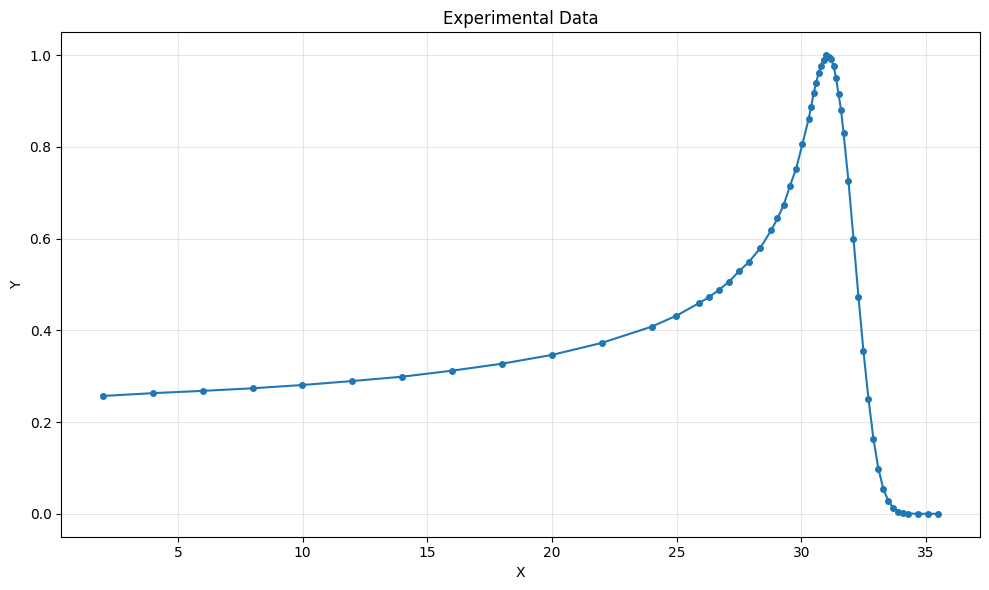

In [57]:
# Load experimental data
df = pd.read_csv(StringIO(exp_data), sep='\t', header=None, names=['x', 'y'])

# Plot the experimental data
plt.figure(figsize=(10, 6))
plt.plot(df['x'], df['y'], marker='o', linestyle='-', linewidth=1.5, markersize=4)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Experimental Data')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# Load MC data from CSV file
print(f"Loading CSV file: {csv_file}")

# Load the data into a DataFrame, skipping comment lines
df_mc = pd.read_csv(csv_file, comment='#', skiprows=0)

# Strip whitespace from column names
df_mc.columns = df_mc.columns.str.strip()

print(f"Columns: {df_mc.columns.tolist()}")

# Rename columns to match expected names (Position (Z) [cm] -> depth, DOSE [MeV/g/prim] -> dose)
df_mc = df_mc.rename(columns={col: 'depth' if 'Position' in col else 'dose' for col in df_mc.columns})

# Convert depth from cm to mm
if 'depth' in df_mc.columns:
    df_mc['depth'] = df_mc['depth'] * 10  # cm to mm

# Normalize dose to max value of 1
if 'dose' in df_mc.columns:
    df_mc['dose'] = df_mc['dose'] / df_mc['dose'].max()

print(f"Data loaded. Shape: {df_mc.shape}")
print(df_mc.head())

Loading CSV file: graph_z_profile_DOSE.csv
Columns: ['Position (Z) [cm]', 'DOSE [MeV/g/prim]']
Data loaded. Shape: (1000, 2)
   depth      dose
0   0.02  0.217282
1   0.06  0.220437
2   0.10  0.217935
3   0.14  0.215064
4   0.18  0.216643


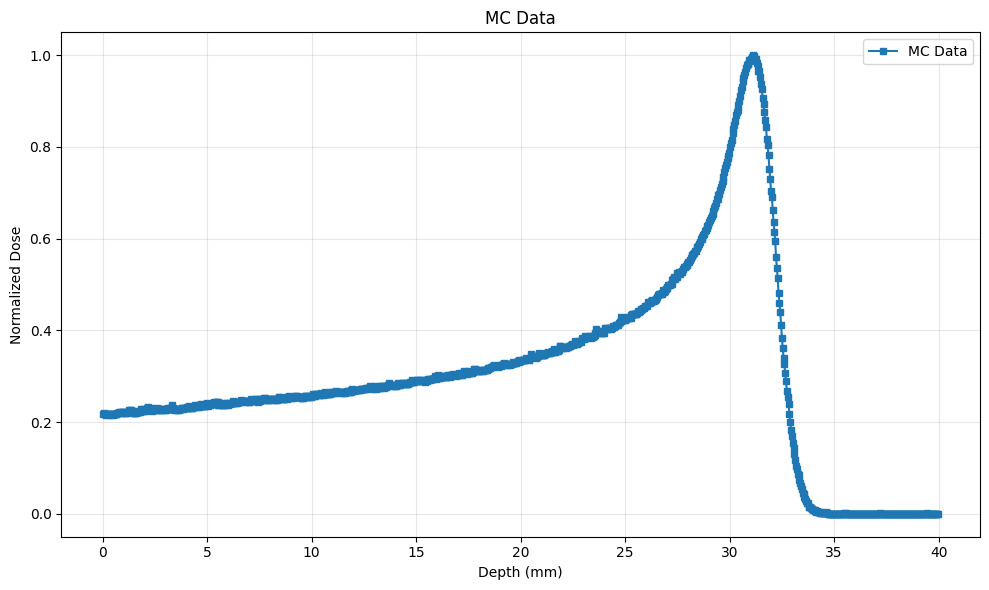

In [59]:
# Plot only the MC data
if 'df_mc' in locals() and not df_mc.empty:
    plt.figure(figsize=(10, 6))
    plt.plot(df_mc['depth'], df_mc['dose'], marker='s', linestyle='-', linewidth=1.5, markersize=5, label='MC Data')
    plt.xlabel('Depth (mm)')
    plt.ylabel('Normalized Dose')
    plt.title('MC Data')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("MC data not loaded")

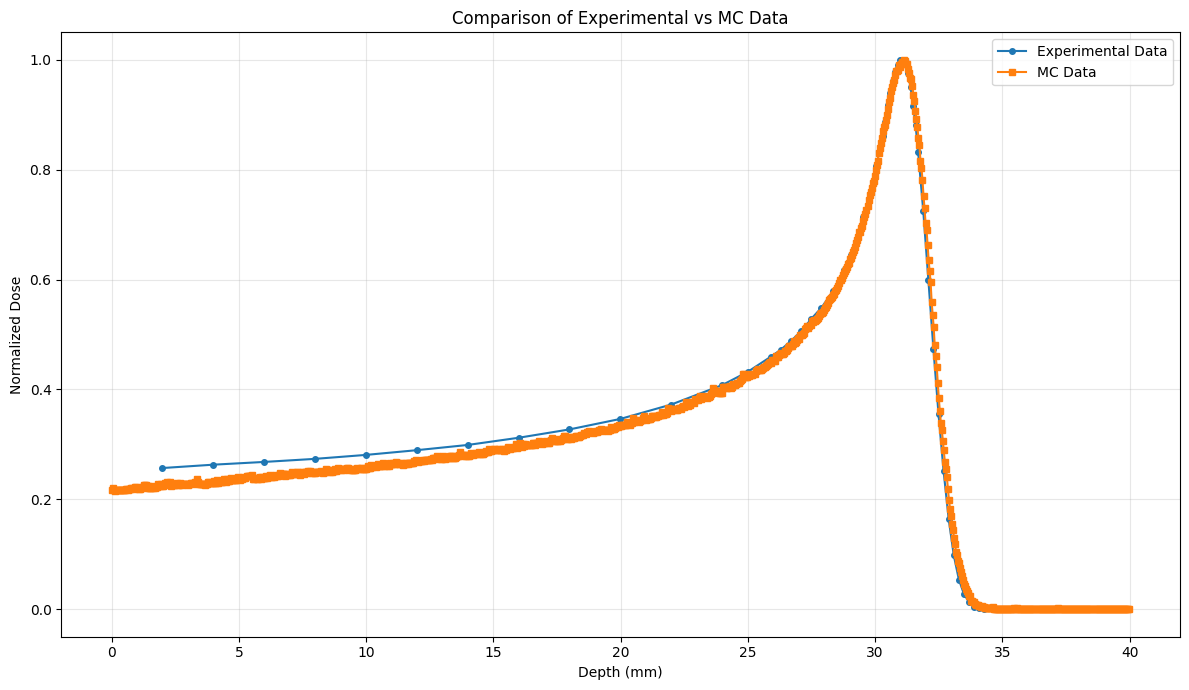

In [60]:
# Comparison of experimental data and MC data
if 'df_mc' in locals() and not df_mc.empty and 'df' in locals() and not df.empty:
    plt.figure(figsize=(12, 7))
    plt.plot(df['x'], df['y'], marker='o', linestyle='-', linewidth=1.5, markersize=4, label='Experimental Data')
    plt.plot(df_mc['depth'], df_mc['dose'], marker='s', linestyle='-', linewidth=1.5, markersize=5, label='MC Data')
    plt.xlabel('Depth (mm)')
    plt.ylabel('Normalized Dose')
    plt.title('Comparison of Experimental vs MC Data')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Both experimental and MC data are required for comparison")

In [61]:
# Calculate metrics for experimental data
if 'df' in locals() and not df.empty:
    metrics_exp = calculate_dose_metrics(df, "Experimental Data")
else:
    print("Experimental data not loaded")
    metrics_exp = None

=== Experimental Data Metrics ===
Range (distance at dose 0.9): 3.1536 cm
Distance at dose 0.1: 3.3084 cm
Drop from 0.9 to 0.1: 0.1548 cm
FWHM: 0.5289 cm
Left edge of FWHM (0.5): 2.6960 cm
Right edge of FWHM (0.5): 3.2248 cm
Inverse of first point value: 3.8911



In [62]:
# Calculate metrics for MC data
if 'df_mc' in locals() and not df_mc.empty and 'df' in locals() and not df.empty:
    # Create interpolation function for MC data
    mc_interp_for_metrics = interp1d(df_mc['depth'], df_mc['dose'], kind='linear', 
                                     bounds_error=False, fill_value='extrapolate')
    
    # Get the first point's x-coordinate from experimental data
    ref_x = df['x'].iloc[0]
    
    # Calculate MC metrics using interpolated value at the experimental first point
    metrics_mc = calculate_dose_metrics(df_mc, "MC Data", ref_x_coord=ref_x, 
                                       interp_func=mc_interp_for_metrics)
else:
    print("MC data or experimental data not loaded")
    metrics_mc = None

=== MC Data Metrics ===
Range (distance at dose 0.9): 3.1599 cm
Distance at dose 0.1: 3.3205 cm
Drop from 0.9 to 0.1: 0.1606 cm
FWHM: 0.5152 cm
Left edge of FWHM (0.5): 2.7164 cm
Right edge of FWHM (0.5): 3.2316 cm
Inverse of first point value: 4.4514



=== Ratio Statistics (exp/MC where dose > 0.1) ===
Number of points with dose > 0.1: 47
Ratio - Mean: 1.0087
Ratio - Min: 0.8021
Ratio - Max: 1.1440
Ratio - Std: 0.0626



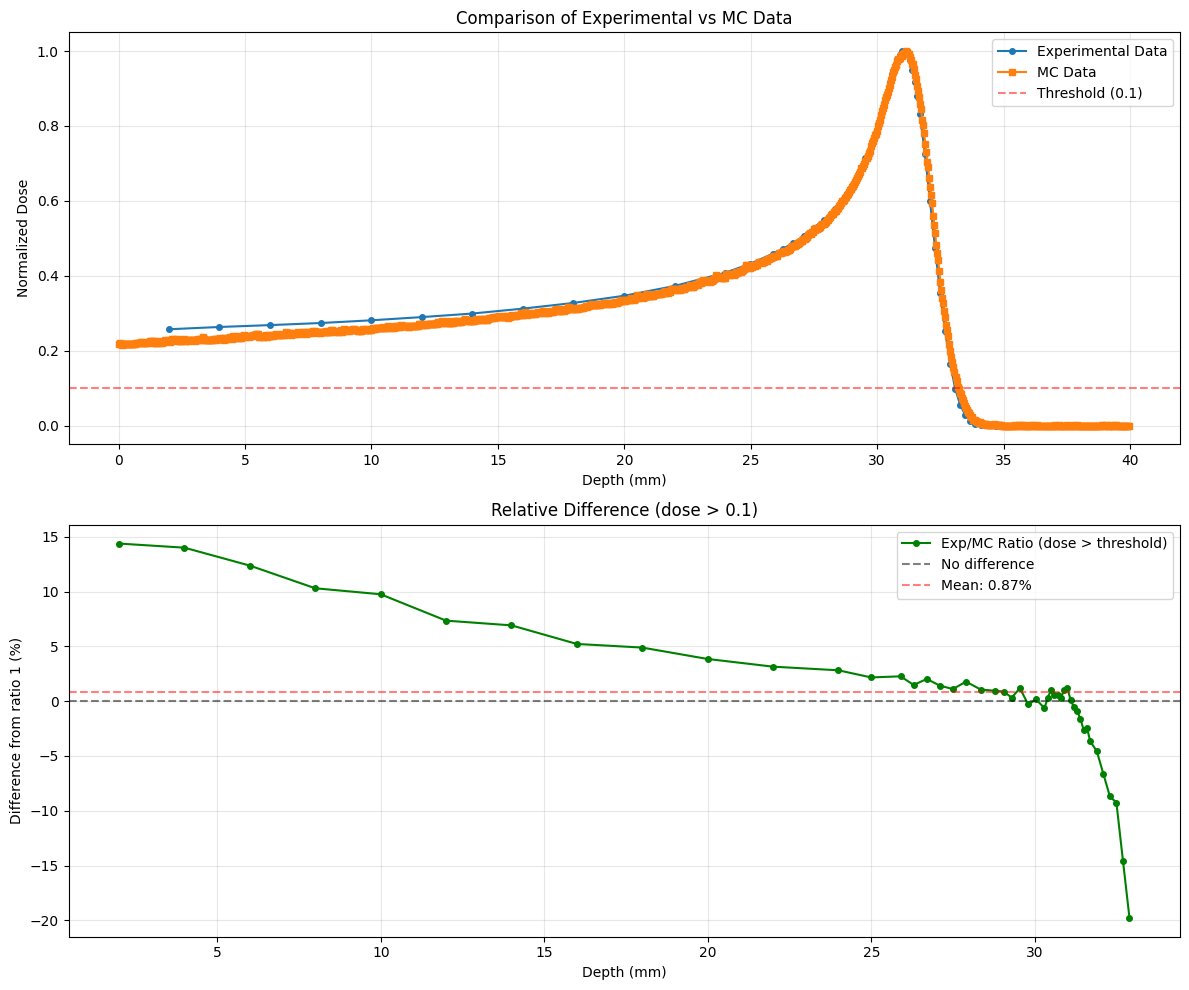

In [63]:
# Calculate ratio between experimental and MC data
if 'df' in locals() and 'df_mc' in locals() and not df.empty and not df_mc.empty:
    # Create interpolation function for MC data
    mc_interp = interp1d(df_mc['depth'], df_mc['dose'], kind='linear', 
                         bounds_error=False, fill_value='extrapolate')
    
    # Interpolate MC values at experimental data points
    df_mc_interp = pd.DataFrame({
        'x': df['x'],
        'mc_dose': mc_interp(df['x'])
    })
    
    # Calculate ratio only where experimental dose > threshold
    ratio = pd.Series(index=df.index, dtype=float)
    valid_mask = df['y'] > THRESHOLD
    ratio[valid_mask] = df.loc[valid_mask, 'y'] / df_mc_interp.loc[valid_mask, 'mc_dose']
    
    print(f"=== Ratio Statistics (exp/MC where dose > {THRESHOLD}) ===")
    print(f"Number of points with dose > {THRESHOLD}: {valid_mask.sum()}")
    print(f"Ratio - Mean: {ratio[valid_mask].mean():.4f}")
    print(f"Ratio - Min: {ratio[valid_mask].min():.4f}")
    print(f"Ratio - Max: {ratio[valid_mask].max():.4f}")
    print(f"Ratio - Std: {ratio[valid_mask].std():.4f}")
    print()
    
    # Plot comparison: experimental data, MC data, and ratio
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Upper plot: dose vs depth
    ax1.plot(df['x'], df['y'], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
             label='Experimental Data')
    ax1.plot(df_mc['depth'], df_mc['dose'], marker='s', linestyle='-', linewidth=1.5, 
             markersize=5, label='MC Data')
    ax1.axhline(y=THRESHOLD, color='r', linestyle='--', alpha=0.5, label=f'Threshold ({THRESHOLD})')
    ax1.set_xlabel('Depth (mm)')
    ax1.set_ylabel('Normalized Dose')
    ax1.set_title('Comparison of Experimental vs MC Data')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Lower plot: ratio of exp/MC as percentage difference from 1
    ratio_percent = (ratio[valid_mask] - 1.0) * 100
    mean_ratio_percent = (ratio[valid_mask].mean() - 1.0) * 100
    
    ax2.plot(df.loc[valid_mask, 'x'], ratio_percent, marker='o', linestyle='-', 
             linewidth=1.5, markersize=4, color='green', label='Exp/MC Ratio (dose > threshold)')
    ax2.axhline(y=0.0, color='k', linestyle='--', alpha=0.5, label='No difference')
    ax2.axhline(y=mean_ratio_percent, color='r', linestyle='--', alpha=0.5, 
                label=f'Mean: {mean_ratio_percent:.2f}%')
    ax2.set_xlabel('Depth (mm)')
    ax2.set_ylabel('Difference from ratio 1 (%)')
    ax2.set_title(f'Relative Difference (dose > {THRESHOLD})')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("Both experimental and MC data are required for ratio calculation")

In [64]:
# Create comparison table of metrics
if 'metrics_exp' in locals() and 'metrics_mc' in locals() and metrics_exp is not None and metrics_mc is not None:
    print("="*90)
    print("FEATURE COMPARISON: EXPERIMENTAL DATA vs MC DATA")
    print("="*90)
    print()
    
    # Create a detailed comparison table
    features = [
        ("Range (dose 90%)", "mm", lambda m: m['dose_09'] if m['dose_09'] is not None else None),
        ("Falloff 90% to 10%", "mm", lambda m: m['dose_drop_09_to_01'] if m['dose_drop_09_to_01'] is not None else None),
        ("FWHM", "mm", lambda m: m['fwhm'] if m['fwhm'] is not None else None),
        ("Max to Plateau Ratio", "-", lambda m: m['first_point_inverse'] if m['first_point_inverse'] is not None else None),
    ]
    
    print(f"{'Feature':<30} {'Unit':<6} {'Experimental':<16} {'MC':<16} {'Absolute Diff':<16} {'Relative Diff (%)':<16}")
    print("-"*100)
    
    for feature_name, unit, getter in features:
        exp_val = getter(metrics_exp)
        mc_val = getter(metrics_mc)
        
        if exp_val is not None and mc_val is not None:
            abs_diff = mc_val - exp_val
            rel_diff = (abs_diff / exp_val) * 100
            
            print(f"{feature_name:<30} {unit:<6} {exp_val:>15.4f} {mc_val:>15.4f} {abs_diff:>15.4f} {rel_diff:>15.2f}%")
        else:
            print(f"{feature_name:<30} {unit:<6} {'N/A':>15} {'N/A':>15} {'N/A':>15} {'N/A':>15}")
    
    print("-"*100)
    print()
    print("Note: Relative difference is calculated as (MC - Exp) / Exp * 100")
    print("      Negative values indicate MC is smaller/lower than Experimental data")
    print()
else:
    print("Metrics not available. Please run the metrics calculation cells first.")

FEATURE COMPARISON: EXPERIMENTAL DATA vs MC DATA

Feature                        Unit   Experimental     MC               Absolute Diff    Relative Diff (%)
----------------------------------------------------------------------------------------------------
Range (dose 90%)               mm             31.5360         31.5988          0.0628            0.20%
Falloff 90% to 10%             mm              1.5476          1.6064          0.0587            3.79%
FWHM                           mm              5.2887          5.1522         -0.1364           -2.58%
Max to Plateau Ratio           -               3.8911          4.4514          0.5603           14.40%
----------------------------------------------------------------------------------------------------

Note: Relative difference is calculated as (MC - Exp) / Exp * 100
      Negative values indicate MC is smaller/lower than Experimental data



In [65]:
df_mc.to_hdf('ccb.h5', key='mc_depth_dose', mode='a')

In [66]:
df.to_hdf('ccb.h5', key='exp_depth_dose', mode='a')